# Assignment 4 - Part 6: Explainable AI for the Assignment 3 CNN

This notebook analyzes the convolutional neural network architecture from Assignment 3 using Explainable AI methods. The Assignment 3 notebook used CIFAR-10, TensorFlow/Keras, normalized images, one-hot labels, and a small CNN built from layer names.

The methods used here are Grad-CAM, SHAP, LIME, and an ELI5-compatible feature-importance fallback. These explanations are approximate. They help us inspect what the model may be using, but they are not perfect causal proof of why a prediction happened.

## Imports and Configuration

We first set the local Keras cache before importing TensorFlow. This matters because the notebook is meant to run locally in VS Code and should not depend on Colab paths. We also create the output folders used by later cells.

What we gain from this step: reproducible paths, fixed random seeds, and clear package availability checks.

In [58]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
os.environ.setdefault("KERAS_HOME", str(PROJECT_ROOT / ".keras"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
EXPLANATION_DIR = OUTPUT_DIR / "xai_explanations"
MODEL_DIR = Path("models")
for path in [OUTPUT_DIR, EXPLANATION_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=UserWarning)

print("Project root:", PROJECT_ROOT)
print("Keras home:", os.environ["KERAS_HOME"])
print("Outputs:", OUTPUT_DIR.resolve())

Project root: d:\SHARIF\TERM7\DATA\HW4\PART6
Keras home: d:\SHARIF\TERM7\DATA\HW4\PART6\.keras
Outputs: D:\SHARIF\TERM7\DATA\HW4\PART6\outputs


The next imports are the modeling and explainability tools. The assignment asks us not to fail silently if optional XAI packages are missing, so each optional import records its status and prints a clear installation note.



In [59]:
import tensorflow as tf
from tensorflow.keras import callbacks, initializers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

tf.keras.utils.set_random_seed(RANDOM_SEED)

optional_imports = {}

try:
    import shap
    optional_imports["shap"] = ("available", getattr(shap, "__version__", "unknown"))
except Exception as exc:
    shap = None
    optional_imports["shap"] = ("missing", repr(exc))

try:
    import lime
    from lime import lime_image
    optional_imports["lime"] = ("available", getattr(lime, "__version__", "unknown"))
except Exception as exc:
    lime = None
    lime_image = None
    optional_imports["lime"] = ("missing", repr(exc))

try:
    import eli5
    from eli5.sklearn import PermutationImportance
    optional_imports["eli5"] = ("available", getattr(eli5, "__version__", "unknown"))
except Exception as exc:
    eli5 = None
    PermutationImportance = None
    optional_imports["eli5"] = ("missing", repr(exc))

try:
    from skimage.segmentation import mark_boundaries, slic
    from skimage.transform import resize
    optional_imports["scikit-image"] = ("available", "import ok")
except Exception as exc:
    mark_boundaries = None
    slic = None
    resize = None
    optional_imports["scikit-image"] = ("missing", repr(exc))

print("TensorFlow:", tf.__version__)
print("Optional package status:")
for package_name, status in optional_imports.items():
    print(f"  {package_name}: {status[0]} ({status[1]})")

missing_packages = [name for name, (status, _) in optional_imports.items() if status != "available"]
if missing_packages:
    print("\nInstall missing XAI packages with:")
    print("python -m pip install shap lime eli5 scikit-image")

TensorFlow: 2.21.0
Optional package status:
  shap: available (0.52.0)
  lime: available (unknown)
  eli5: available (0.16.0)
  scikit-image: available (import ok)


## Inspect Assignment 3 CNN Resources



In [60]:
def existing_paths(candidates):
    return [path for path in candidates if path.exists()]


data_root = PROJECT_ROOT.parents[1] if len(PROJECT_ROOT.parents) >= 2 else PROJECT_ROOT
assignment3_candidates = [
    PROJECT_ROOT / "Assignment3_CNNs.ipynb",
    data_root / "HW3" / "CNN" / "Assignment3_CNNs.ipynb",
]
assignment3_paths = existing_paths(assignment3_candidates)

model_search_roots = [PROJECT_ROOT, data_root / "HW3"]
saved_model_candidates = []
for root in model_search_roots:
    if root.exists():
        saved_model_candidates.extend(root.rglob("*.keras"))
        saved_model_candidates.extend(root.rglob("*.h5"))
        saved_model_candidates.extend(root.rglob("saved_model.pb"))

# Keep only resources that look related to Assignment 3 or the current workspace.
saved_model_candidates = sorted(set(saved_model_candidates))

print("Assignment 3 notebook candidates found:")
for path in assignment3_paths:
    print(" -", path)

print("\nSaved model candidates found:")
if saved_model_candidates:
    for path in saved_model_candidates[:20]:
        print(" -", path)
else:
    print(" - none")

if assignment3_paths:
    assignment3_path = assignment3_paths[0]
    assignment3_text = assignment3_path.read_text(encoding="utf-8", errors="ignore")
    print("\nAssignment 3 signals:")
    print("  CIFAR-10 mentioned:", "cifar10" in assignment3_text.lower() or "cifar-10" in assignment3_text.lower())
    print("  Conv2D mentioned:", "Conv2D" in assignment3_text)
    print("  Baseline layer names mentioned:", "Conv2D_3x3_32_1" in assignment3_text)
else:
    assignment3_path = None
    print("\nAssignment 3 notebook was not found. A fallback would be required.")

Assignment 3 notebook candidates found:
 - d:\SHARIF\TERM7\DATA\HW3\CNN\Assignment3_CNNs.ipynb

Saved model candidates found:
 - d:\SHARIF\TERM7\DATA\HW4\PART6\.keras

Assignment 3 signals:
  CIFAR-10 mentioned: True
  Conv2D mentioned: True
  Baseline layer names mentioned: True


**Resource decision.** this notebook reconstructs the Assignment 3 baseline CNN architecture and trains it lightly. This matters because XAI should explain the model family used in Assignment 3, not a new unrelated architecture.

## Load Dataset and Apply Assignment 3 Preprocessing

Assignment 3 used CIFAR-10 from Keras. We load the same dataset and apply the same preprocessing: images become `float32` in the `[0, 1]` range, and labels become one-hot vectors for Keras training.


In [61]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0
y_train_labels = y_train_raw.reshape(-1)
y_test_labels = y_test_raw.reshape(-1)
num_classes = len(class_names)
y_train_enc = to_categorical(y_train_labels, num_classes)
y_test_enc = to_categorical(y_test_labels, num_classes)

print("Training images shape:", x_train.shape)
print("Test images shape:", x_test.shape)
print("Number of classes:", num_classes)
print("Class names:", class_names)
print("Pixel range after preprocessing:", float(x_train.min()), "to", float(x_train.max()))

Training images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Pixel range after preprocessing: 0.0 to 1.0


The grid below is a quick sanity check. CIFAR-10 images are tiny, so explanations later should be interpreted carefully.


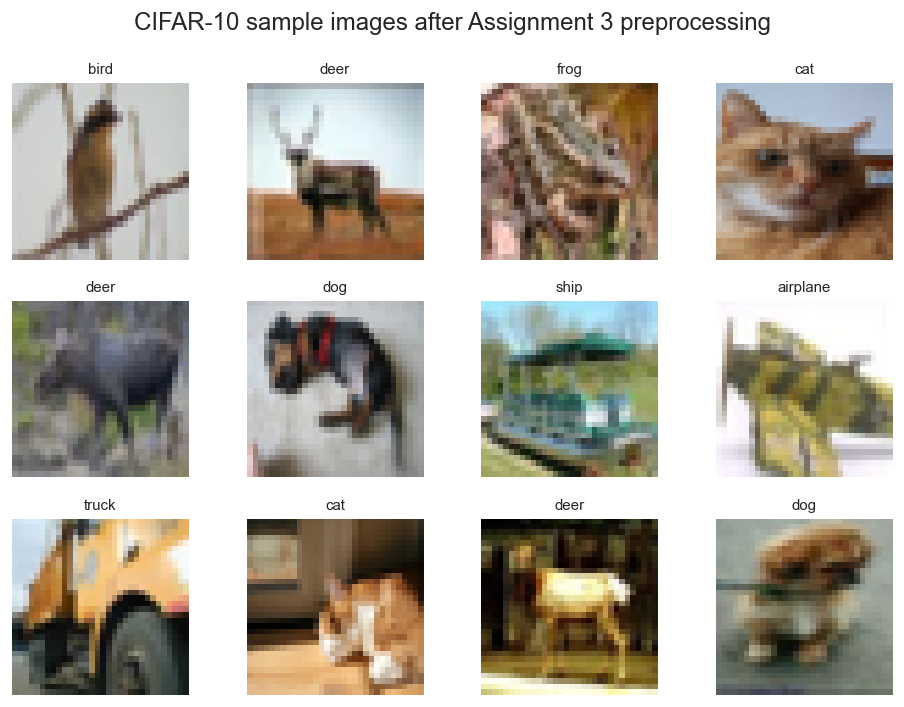

In [62]:
rng = np.random.default_rng(RANDOM_SEED)
sample_indices = rng.choice(len(x_train), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for ax, idx in zip(axes.ravel(), sample_indices):
    ax.imshow(x_train[idx])
    ax.set_title(class_names[y_train_labels[idx]], fontsize=9)
    ax.axis("off")
fig.suptitle("CIFAR-10 sample images after Assignment 3 preprocessing")
plt.tight_layout()
fig.savefig(EXPLANATION_DIR / "cifar10_sample_grid.png", bbox_inches="tight")
plt.show()

## Rebuild the Assignment 3 CNN Model

The next cells recreate the Assignment 3 model wrapper and baseline architecture. Grad-CAM requires at least one convolutional layer because it uses gradients flowing into convolutional feature maps. The last convolutional layer is especially useful because it contains the most class-specific spatial features before the classifier flattens them.


In [63]:
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,
    patience=2,
    restore_best_weights=True,
)


def create_model(
    hidden_layers=None,
    input_size=None,
    no_classes=None,
    activation_func="relu",
    l1_reg=0.0,
    l2_reg=0.0,
    learning_rate=0.001,
    learning_rate_decay=0.95,
    dropout_rate=0.0,
    weight_initializer="",
    optimizer_name="adam",
    regularization_type="kernel_regularizer",
):
    if hidden_layers is None:
        hidden_layers = [
            "Conv2D_3x3_10_1",
            "MaxPooling2D_2x2_0",
            "Conv2D_5x5_20_1",
            "AveragePooling2D_2x2_1",
            "Flatten",
            "Dense_30",
        ]
    if input_size is None:
        input_size = x_train.shape[1:]
    if no_classes is None:
        no_classes = y_train_enc.shape[1]

    if weight_initializer == "RandomNormal":
        weight_initializer = initializers.RandomNormal(seed=RANDOM_SEED)
    elif weight_initializer == "RandomUniform":
        weight_initializer = initializers.RandomUniform(seed=RANDOM_SEED)
    elif weight_initializer == "Zeros":
        weight_initializer = initializers.Zeros()
    elif weight_initializer == "GlorotUniform":
        weight_initializer = initializers.GlorotUniform(seed=RANDOM_SEED)
    elif weight_initializer == "GlorotNormal":
        weight_initializer = initializers.GlorotNormal(seed=RANDOM_SEED)
    else:
        weight_initializer = None

    regularizer = None
    if l1_reg and l2_reg:
        regularizer = l1_l2(l1=l1_reg, l2=l2_reg)
    elif l1_reg:
        regularizer = l1(l1_reg)
    elif l2_reg:
        regularizer = l2(l2_reg)

    model = Sequential(name="assignment3_baseline_cnn")
    model.add(Input(shape=input_size, name="assignment3_input"))

    conv_count = 0
    dense_count = 0
    pool_count = 0

    for itr, layer in enumerate(hidden_layers):
        layer_specs = layer.split("_")
        layer_type = layer_specs[0]

        if layer_type == "Dense":
            dense_count += 1
            n_l = int(layer_specs[1])
            layer_params = {
                "activation": activation_func,
                "kernel_initializer": weight_initializer,
                "name": f"dense_{dense_count}",
            }
            if regularizer is not None:
                layer_params[regularization_type] = regularizer
            model.add(Dense(n_l, **layer_params))

        elif layer_type == "Flatten":
            model.add(Flatten(name="flatten"))

        elif layer_type == "Conv2D":
            conv_count += 1
            kernel_size = tuple(int(v) for v in layer_specs[1].split("x"))
            filters = int(layer_specs[2])
            stride = int(layer_specs[3])
            layer_params = {
                "filters": filters,
                "kernel_size": kernel_size,
                "activation": activation_func,
                "kernel_initializer": weight_initializer,
                "name": f"conv2d_{conv_count}",
            }
            if stride:
                layer_params["strides"] = stride
            if regularizer is not None:
                layer_params[regularization_type] = regularizer
            model.add(Conv2D(**layer_params))

        elif layer_type in ["MaxPooling2D", "AveragePooling2D"]:
            pool_count += 1
            pool_size = tuple(int(v) for v in layer_specs[1].split("x"))
            stride = int(layer_specs[2])
            layer_params = {"pool_size": pool_size, "name": f"{layer_type.lower()}_{pool_count}"}
            if stride:
                layer_params["strides"] = stride
            if layer_type == "MaxPooling2D":
                model.add(MaxPooling2D(**layer_params))
            else:
                model.add(AveragePooling2D(**layer_params))

        if dropout_rate and itr % 2 == 0 and layer_type not in ["Flatten", "MaxPooling2D", "AveragePooling2D"]:
            model.add(Dropout(dropout_rate, seed=RANDOM_SEED, name=f"dropout_{itr}"))

    model.add(Dense(no_classes, activation="softmax", name="predictions"))

    if optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "RMSprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "Adadelta":
        optimizer = tf.keras.optimizers.Adadelta(learning_rate=learning_rate, rho=learning_rate_decay)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=learning_rate_decay)

    model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model


baseline_architecture = [
    "Conv2D_3x3_32_1",
    "MaxPooling2D_2x2_0",
    "Conv2D_3x3_64_1",
    "MaxPooling2D_2x2_0",
    "Conv2D_3x3_64_1",
    "Flatten",
    "Dense_64",
    "Dense_32",
]

model = create_model(
    hidden_layers=baseline_architecture,
    activation_func="relu",
    learning_rate=0.001,
    dropout_rate=0.2,
)

model.summary()

Model: "assignment3_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_1 (MaxPooling2D)   │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_2 (MaxPooling2D)   │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,330 (485.66 KB)

 Trainable params: 124,330 (485.66 KB)

 Non-trainable params: 0 (0.00 B)

we train this reconstructed model lightly. The training subset keeps runtime reasonable while still producing both correct and incorrect predictions for analysis.


In [64]:
TRAIN_LIMIT = 4000
EPOCHS = 3
BATCH_SIZE = 64

train_indices, _ = train_test_split(
    np.arange(len(x_train)),
    train_size=TRAIN_LIMIT,
    stratify=y_train_labels,
    random_state=RANDOM_SEED,
)

history = model.fit(
    x_train[train_indices],
    y_train_enc[train_indices],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=2,
)

history_df = pd.DataFrame(history.history)
display(history_df)

Epoch 1/3
50/50 - 4s - 71ms/step - accuracy: 0.1241 - loss: 2.2877 - val_accuracy: 0.1587 - val_loss: 2.2434
Epoch 2/3
50/50 - 1s - 23ms/step - accuracy: 0.2084 - loss: 2.1247 - val_accuracy: 0.2688 - val_loss: 2.0057
Epoch 3/3
50/50 - 1s - 22ms/step - accuracy: 0.2688 - loss: 1.9462 - val_accuracy: 0.3438 - val_loss: 1.8769


,accuracy,loss,val_accuracy,val_loss
0,0.124063,2.287705,0.15875,2.243406
1,0.208438,2.124661,0.26875,2.005718
2,0.268750,1.946171,0.34375,1.876860


The training curves help us check whether the light training run learned any signal. This is not meant to maximize CIFAR-10 accuracy; it is meant to produce a usable Assignment 3 CNN for XAI.


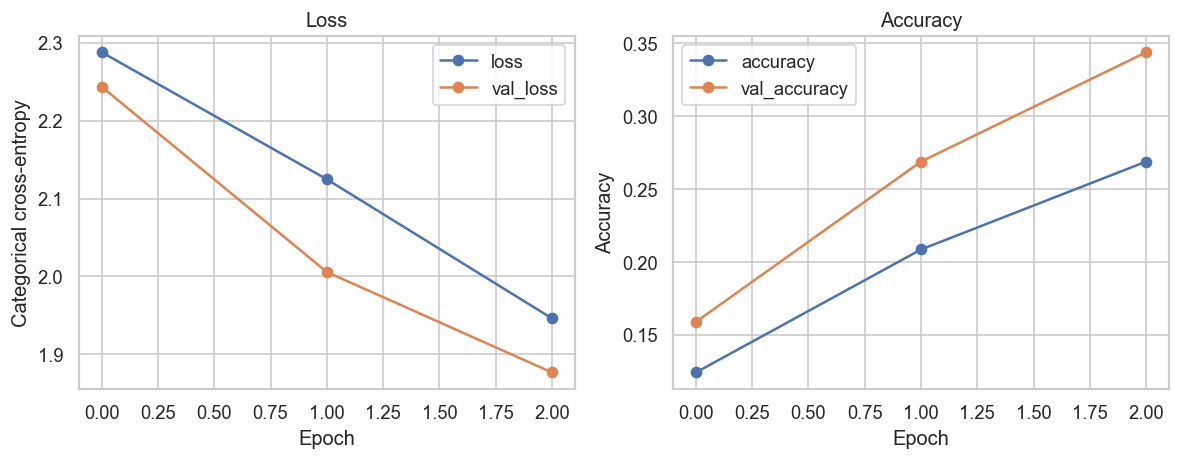

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
history_df[["loss", "val_loss"]].plot(ax=axes[0], marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical cross-entropy")

accuracy_cols = [col for col in history_df.columns if "accuracy" in col]
history_df[accuracy_cols].plot(ax=axes[1], marker="o")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
fig.savefig(EXPLANATION_DIR / "training_curves.png", bbox_inches="tight")
plt.show()

Now we verify that the model has convolutional layers and automatically identify the last one. The last convolutional layer will be used by Grad-CAM.

What we gain from this step: a concrete target layer for class activation maps.

In [66]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found. Grad-CAM requires a convolutional layer.")


conv_layers = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
last_conv_layer_name = find_last_conv_layer(model)
print("Convolutional layers:", conv_layers)
print("Last convolutional layer:", last_conv_layer_name)

Convolutional layers: ['conv2d_1', 'conv2d_2', 'conv2d_3']
Last convolutional layer: conv2d_3


## Model Evaluation and Sample Selection

We predict on a small test subset, compute standard classification metrics, and select correctly classified and misclassified samples. We use high-confidence examples first because they give clearer cases for explanation.


In [67]:
def predict_scan(scan_limit):
    scan_indices = np.arange(min(scan_limit, len(x_test)))
    probabilities = model.predict(x_test[scan_indices], batch_size=128, verbose=0)
    predicted = np.argmax(probabilities, axis=1)
    confidence = np.max(probabilities, axis=1)
    true = y_test_labels[scan_indices]
    df = pd.DataFrame({
        "index": scan_indices,
        "true_label": [class_names[i] for i in true],
        "predicted_label": [class_names[i] for i in predicted],
        "true_class": true,
        "predicted_class": predicted,
        "confidence": confidence,
        "correct_or_wrong": np.where(predicted == true, "correct", "wrong"),
    })
    return df, probabilities


prediction_df, scan_probabilities = predict_scan(500)
if (prediction_df["correct_or_wrong"] == "wrong").sum() < 3:
    prediction_df, scan_probabilities = predict_scan(2000)

scan_indices = prediction_df["index"].to_numpy()
scan_true = prediction_df["true_class"].to_numpy()
scan_pred = prediction_df["predicted_class"].to_numpy()

accuracy = accuracy_score(scan_true, scan_pred)
print(f"Subset accuracy: {accuracy:.3f}")
print(classification_report(scan_true, scan_pred, target_names=class_names, zero_division=0))

correct_df = prediction_df[prediction_df["correct_or_wrong"] == "correct"].sort_values("confidence", ascending=False)
wrong_df = prediction_df[prediction_df["correct_or_wrong"] == "wrong"].sort_values("confidence", ascending=False)

selected_correct_df = correct_df.head(5).copy()
selected_wrong_df = wrong_df.head(5).copy()
selected_analysis_wrong_df = selected_wrong_df.head(3).copy()

selected_samples_df = pd.concat([
    selected_correct_df.assign(selection_group="correct"),
    selected_wrong_df.assign(selection_group="misclassified"),
], ignore_index=True)

prediction_df.to_csv(OUTPUT_DIR / "xai_prediction_analysis.csv", index=False)
selected_samples_df.to_csv(OUTPUT_DIR / "selected_xai_samples.csv", index=False)

display(prediction_df.head(10))
display(selected_samples_df)
print("Correct samples selected:", len(selected_correct_df))
print("Misclassified samples selected:", len(selected_wrong_df))

Subset accuracy: 0.308
              precision    recall  f1-score   support

    airplane       0.52      0.19      0.28        57
  automobile       0.26      0.66      0.38        41
        bird       0.00      0.00      0.00        51
         cat       0.24      0.14      0.18        49
        deer       1.00      0.03      0.05        40
         dog       0.26      0.50      0.34        48
        frog       0.32      0.65      0.42        54
       horse       0.19      0.26      0.22        47
        ship       0.42      0.28      0.34        57
       truck       0.50      0.38      0.43        56

    accuracy                           0.31       500
   macro avg       0.37      0.31      0.26       500
weighted avg       0.37      0.31      0.27       500



,index,true_label,predicted_label,true_class,predicted_class,confidence,correct_or_wrong
0,0,cat,cat,3,3,0.197700,correct
1,1,ship,ship,8,8,0.330953,correct
2,2,ship,automobile,8,1,0.256585,wrong
3,3,airplane,automobile,0,1,0.282209,wrong
4,4,frog,frog,6,6,0.211662,correct
5,5,frog,frog,6,6,0.188319,correct
6,6,automobile,truck,1,9,0.264405,wrong
7,7,frog,frog,6,6,0.252255,correct
8,8,cat,dog,3,5,0.183010,wrong
9,9,automobile,automobile,1,1,0.302196,correct


,index,true_label,predicted_label,true_class,predicted_class,confidence,correct_or_wrong,selection_group
0,286,automobile,automobile,1,1,0.471300,correct,correct
1,493,automobile,automobile,1,1,0.461243,correct,correct
2,104,automobile,automobile,1,1,0.454225,correct,correct
3,290,automobile,automobile,1,1,0.446024,correct,correct
4,37,automobile,automobile,1,1,0.445228,correct,correct
5,150,ship,automobile,8,1,0.465777,wrong,misclassified
6,451,truck,automobile,9,1,0.443042,wrong,misclassified
7,415,truck,automobile,9,1,0.431410,wrong,misclassified
8,13,horse,automobile,7,1,0.387270,wrong,misclassified
9,280,truck,automobile,9,1,0.365688,wrong,misclassified


Correct samples selected: 5
Misclassified samples selected: 5


The confusion matrix summarizes which classes are being mixed up in the prediction subset. Because the model is trained lightly, we expect several mistakes; those mistakes are useful for Part 6 analysis.


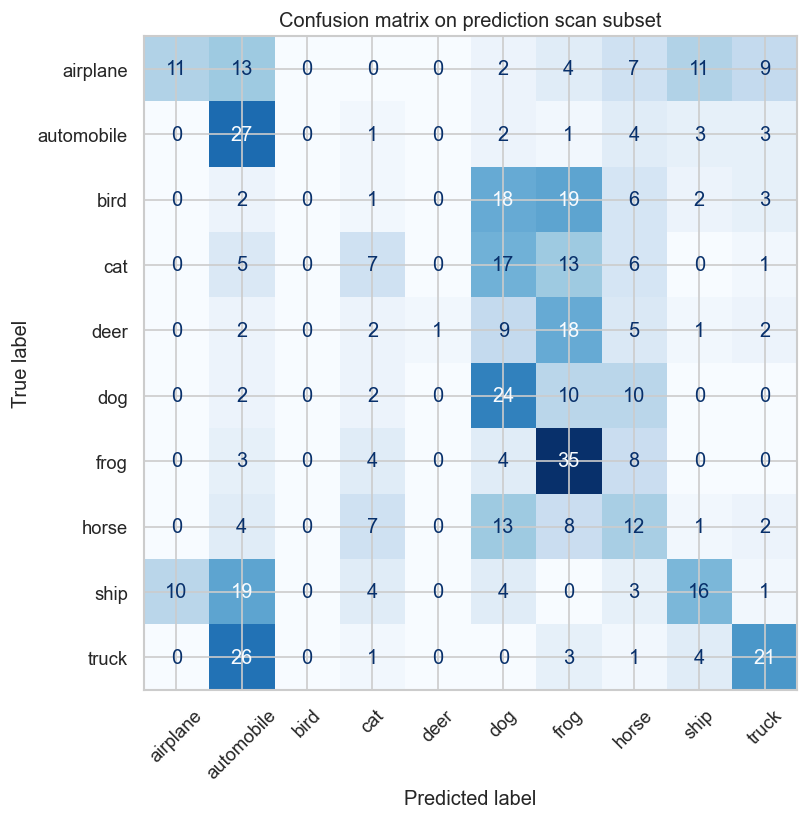

In [68]:
cm = confusion_matrix(scan_true, scan_pred, labels=np.arange(num_classes))
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False,
    cmap="Blues",
)
ax.set_title("Confusion matrix on prediction scan subset")
plt.tight_layout()
fig.savefig(EXPLANATION_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

Next we visualize the selected correct and misclassified images. This makes the later explanation panels easier to read.


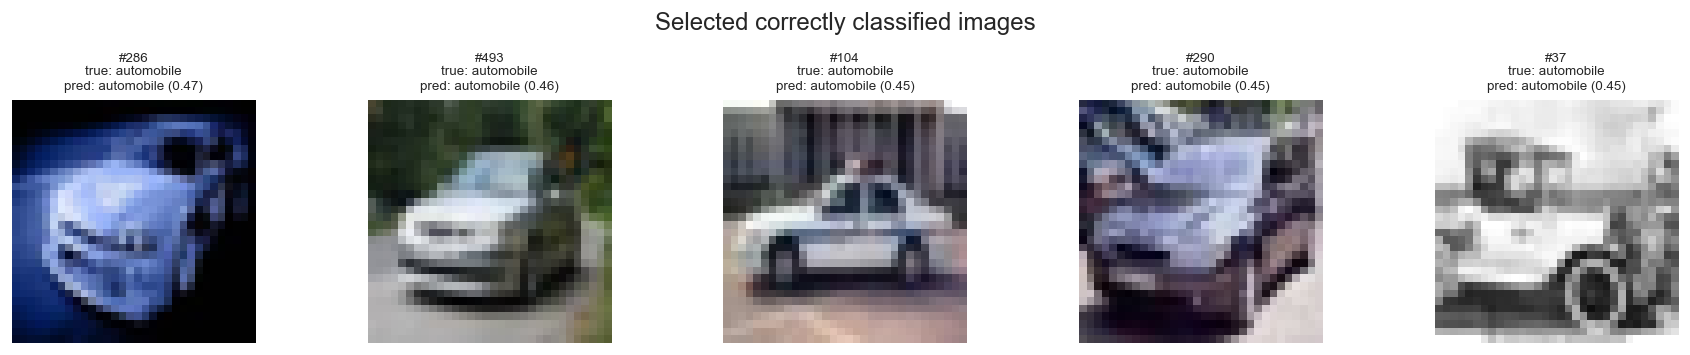

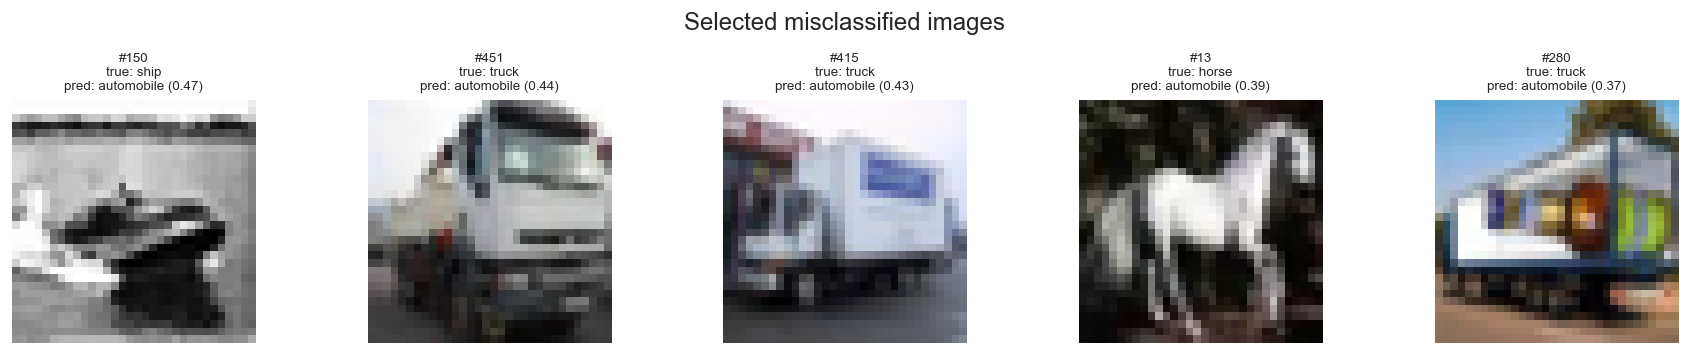

In [69]:
def plot_selected_images(df, title, filename):
    count = len(df)
    cols = min(5, count)
    rows = int(np.ceil(count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, df.iterrows()):
        idx = int(row["index"])
        ax.imshow(x_test[idx])
        ax.set_title(
            f"#{idx}\ntrue: {row['true_label']}\npred: {row['predicted_label']} ({row['confidence']:.2f})",
            fontsize=8,
        )
        ax.axis("off")
    for ax in axes[count:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    fig.savefig(EXPLANATION_DIR / filename, bbox_inches="tight")
    plt.show()


plot_selected_images(selected_correct_df, "Selected correctly classified images", "selected_correct_images.png")
plot_selected_images(selected_wrong_df, "Selected misclassified images", "selected_misclassified_images.png")

## Grad-CAM Implementation

Grad-CAM uses gradients of a class score with respect to convolutional feature maps. It highlights spatial regions that had strong influence on the selected class prediction. The map is coarse because the last convolutional layer has much lower spatial resolution than the input image.


In [70]:
def make_gradcam_heatmap(image, model, last_conv_layer_name, pred_index=None):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_layer_model = tf.keras.models.Model(model.inputs, last_conv_layer.output)

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    use_layer = False
    for layer in model.layers:
        if layer.name == last_conv_layer_name:
            use_layer = True
            continue
        if use_layer:
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)
    classifier_model = tf.keras.models.Model(classifier_input, x)

    image_batch = tf.expand_dims(tf.cast(image, tf.float32), axis=0)
    with tf.GradientTape() as tape:
        conv_outputs = last_conv_layer_model(image_batch, training=False)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs, training=False)
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    if grads is None:
        raise ValueError("Grad-CAM gradients are None; the classifier graph is not connected to the conv outputs.")
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.linalg.matvec(conv_outputs, pooled_grads)
    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_value + tf.keras.backend.epsilon())
    heatmap = heatmap.numpy()
    if not np.all(np.isfinite(heatmap)):
        raise ValueError("Grad-CAM heatmap contains non-finite values.")
    return heatmap


def resize_heatmap(heatmap, image_shape=(32, 32)):
    resized = tf.image.resize(heatmap[..., np.newaxis], image_shape, method="bilinear").numpy()[..., 0]
    resized = np.clip(resized, 0, 1)
    return resized


def overlay_heatmap_on_image(image, heatmap, alpha=0.4):
    heatmap_resized = resize_heatmap(heatmap, image.shape[:2])
    cmap = plt.colormaps["jet"]
    colored_heatmap = cmap(heatmap_resized)[..., :3]
    overlay = np.clip((1 - alpha) * image + alpha * colored_heatmap, 0, 1)
    return overlay


def describe_heatmap_focus(heatmap):
    heatmap_resized = resize_heatmap(heatmap, (32, 32))
    yy, xx = np.indices(heatmap_resized.shape)
    total = heatmap_resized.sum() + 1e-8
    cx = float((xx * heatmap_resized).sum() / total) / (heatmap_resized.shape[1] - 1)
    cy = float((yy * heatmap_resized).sum() / total) / (heatmap_resized.shape[0] - 1)
    vertical = "upper" if cy < 0.34 else "lower" if cy > 0.66 else "middle"
    horizontal = "left" if cx < 0.34 else "right" if cx > 0.66 else "center"
    peak_y, peak_x = np.unravel_index(np.argmax(heatmap_resized), heatmap_resized.shape)
    return {
        "center_of_mass": f"{vertical}-{horizontal}",
        "peak_pixel": (int(peak_y), int(peak_x)),
        "peak_value": float(heatmap_resized[peak_y, peak_x]),
    }


def compute_gradcam_for_df(df):
    records = []
    for _, row in df.iterrows():
        idx = int(row["index"])
        pred_class = int(row["predicted_class"])
        heatmap = make_gradcam_heatmap(x_test[idx], model, last_conv_layer_name, pred_class)
        overlay = overlay_heatmap_on_image(x_test[idx], heatmap)
        focus = describe_heatmap_focus(heatmap)
        records.append({
            "index": idx,
            "heatmap": heatmap,
            "overlay": overlay,
            "focus": focus,
        })
    return records


gradcam_correct = compute_gradcam_for_df(selected_correct_df.head(3))
gradcam_wrong = compute_gradcam_for_df(selected_wrong_df.head(5))

print("Grad-CAM correct heatmap shapes:", [record["heatmap"].shape for record in gradcam_correct])
print("Grad-CAM wrong heatmap shapes:", [record["heatmap"].shape for record in gradcam_wrong])
print("All Grad-CAM heatmaps finite:", all(np.all(np.isfinite(r["heatmap"])) for r in gradcam_correct + gradcam_wrong))

Grad-CAM correct heatmap shapes: [(4, 4), (4, 4), (4, 4)]
Grad-CAM wrong heatmap shapes: [(4, 4), (4, 4), (4, 4), (4, 4), (4, 4)]
All Grad-CAM heatmaps finite: True


We now plot Grad-CAM overlays for correct and misclassified samples. Red/yellow regions indicate stronger class evidence for the predicted class.

What we gain from this step: a direct comparison between where the model looks when it is right and when it is wrong.

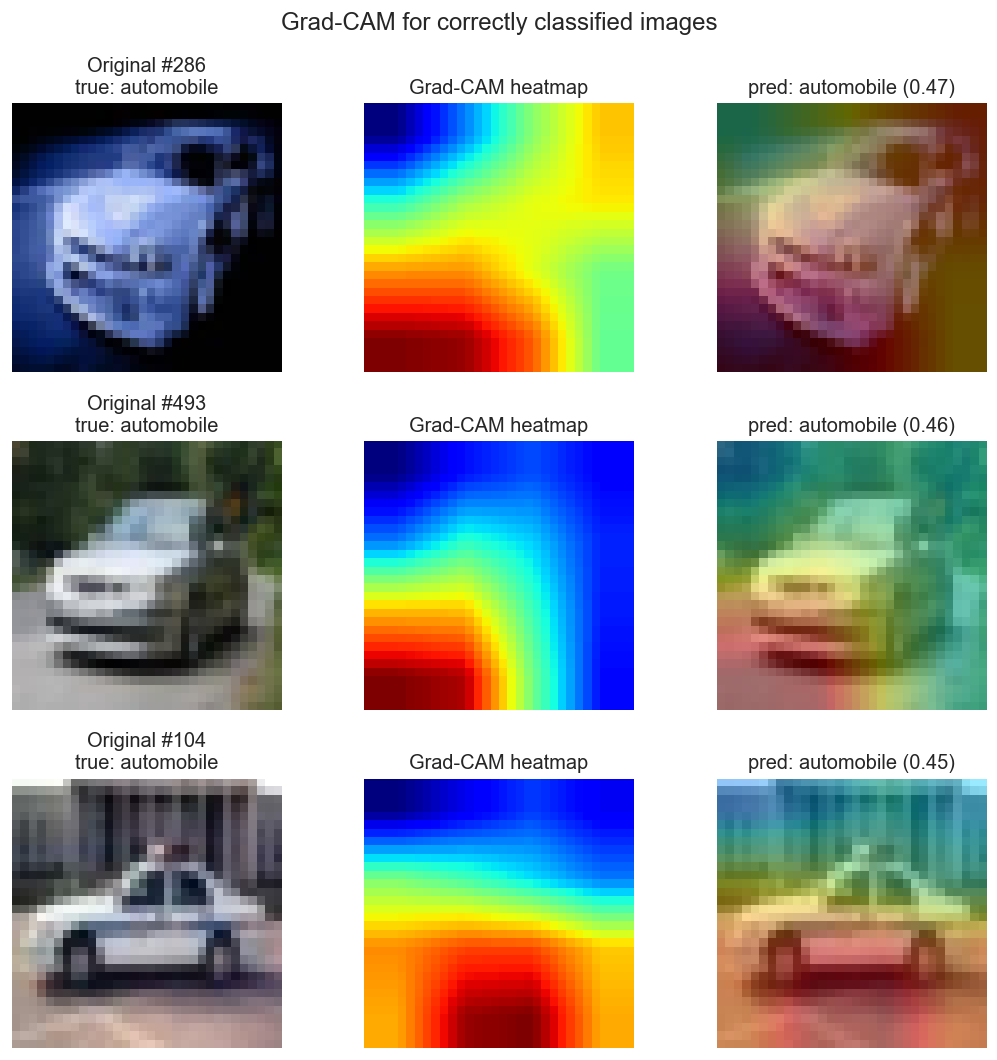

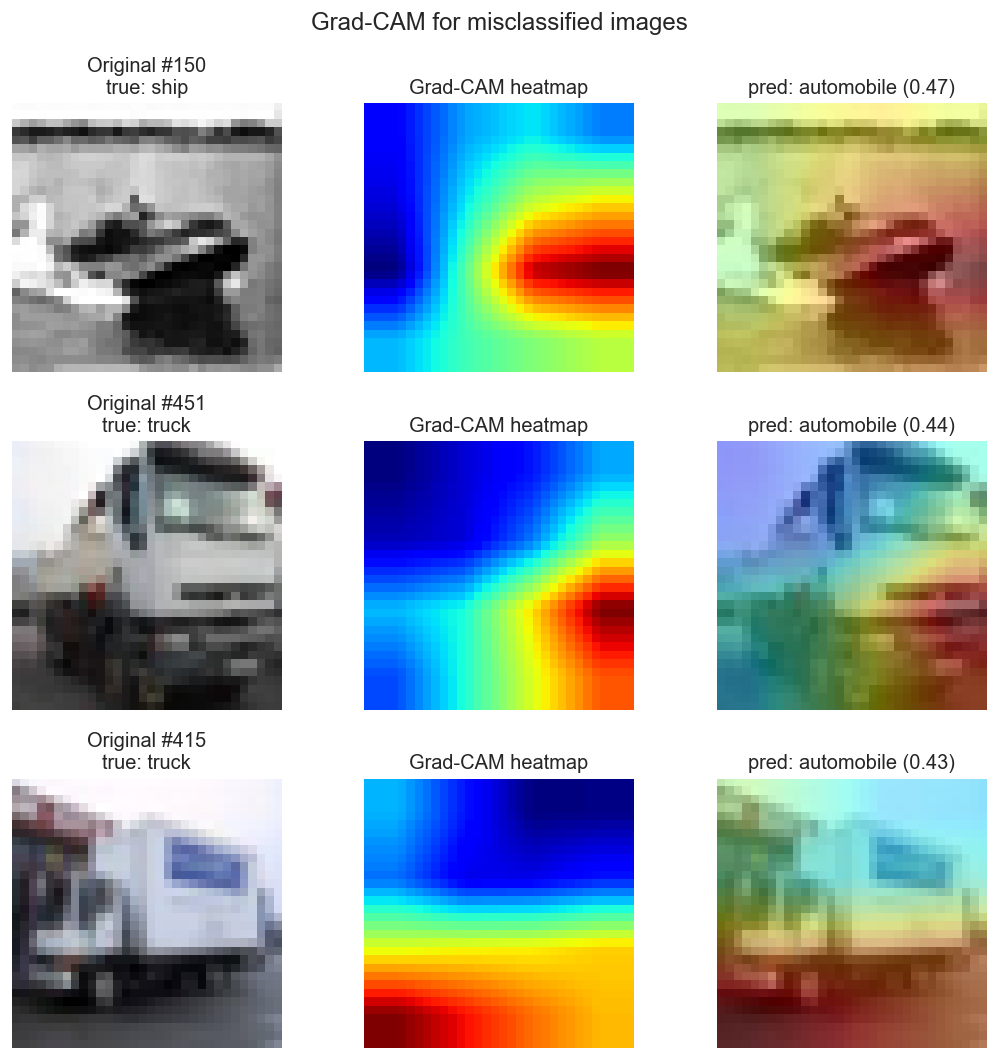

In [71]:
def plot_gradcam_panel(df, gradcam_records, title, filename):
    count = len(gradcam_records)
    fig, axes = plt.subplots(count, 3, figsize=(9, 3 * count))
    if count == 1:
        axes = axes[np.newaxis, :]

    for row_ax, record in zip(axes, gradcam_records):
        sample = df[df["index"] == record["index"]].iloc[0]
        idx = int(record["index"])
        heatmap_resized = resize_heatmap(record["heatmap"], x_test[idx].shape[:2])

        row_ax[0].imshow(x_test[idx])
        row_ax[0].set_title(f"Original #{idx}\ntrue: {sample['true_label']}")
        row_ax[0].axis("off")

        row_ax[1].imshow(heatmap_resized, cmap="jet")
        row_ax[1].set_title("Grad-CAM heatmap")
        row_ax[1].axis("off")

        row_ax[2].imshow(record["overlay"])
        row_ax[2].set_title(f"pred: {sample['predicted_label']} ({sample['confidence']:.2f})")
        row_ax[2].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    fig.savefig(EXPLANATION_DIR / filename, bbox_inches="tight")
    plt.show()


plot_gradcam_panel(selected_correct_df, gradcam_correct, "Grad-CAM for correctly classified images", "gradcam_correct.png")
plot_gradcam_panel(selected_wrong_df, gradcam_wrong[:3], "Grad-CAM for misclassified images", "gradcam_misclassified.png")

**Grad-CAM interpretation.** For correct predictions, useful heat should ideally land on the main object region. For misclassified images, heat on background, edges, or visually ambiguous parts can suggest why the wrong class received evidence. Because CIFAR-10 images are only 32 by 32 pixels and the last convolutional map is small, the heatmap should be read as a coarse focus signal, not a pixel-perfect explanation.

## SHAP Explanation

SHAP explains predictions as feature contributions. For images, raw pixel explanations are high-dimensional and can be noisy, so we use a small background set, explain a few selected images, and aggregate pixel-level SHAP values into image regions for summary and local plots.


In [72]:
shap_results = {
    "available": False,
    "reason": "",
    "values": None,
    "sample_indices": [],
    "predicted_classes": [],
    "region_values": None,
    "region_names": None,
    "background_base_probs": None,
}


def aggregate_regions(values, grid_size=4, signed=True):
    height, width, channels = values.shape
    region_values = []
    region_names = []
    for gy in range(grid_size):
        for gx in range(grid_size):
            y0 = gy * height // grid_size
            y1 = (gy + 1) * height // grid_size
            x0 = gx * width // grid_size
            x1 = (gx + 1) * width // grid_size
            patch = values[y0:y1, x0:x1, :]
            score = patch.sum() if signed else np.abs(patch).sum()
            region_values.append(float(score))
            region_names.append(f"r{gy + 1}c{gx + 1}")
    return np.array(region_values), region_names


if optional_imports["shap"][0] == "available":
    try:
        background_indices = train_indices[:20]
        shap_sample_indices = pd.concat([
            selected_correct_df.head(1),
            selected_analysis_wrong_df,
        ])["index"].astype(int).to_list()

        shap_background = x_train[background_indices]
        shap_images = x_test[shap_sample_indices]
        shap_predictions = model.predict(shap_images, verbose=0)
        shap_pred_classes = np.argmax(shap_predictions, axis=1)
        background_probs = model.predict(shap_background, verbose=0).mean(axis=0)

        explainer = shap.GradientExplainer(model, shap_background)
        shap_values = explainer.shap_values(shap_images)
        shap_values = np.asarray(shap_values)

        # SHAP 0.52 returns (samples, height, width, channels, classes) for this Keras model.
        if shap_values.ndim == 5:
            class_specific_values = np.stack([
                shap_values[i, :, :, :, shap_pred_classes[i]]
                for i in range(len(shap_sample_indices))
            ])
        elif isinstance(shap_values, list):
            class_specific_values = np.stack([
                shap_values[shap_pred_classes[i]][i]
                for i in range(len(shap_sample_indices))
            ])
        else:
            raise ValueError(f"Unexpected SHAP value shape: {shap_values.shape}")

        region_rows = []
        region_names = None
        for sample_i, values in enumerate(class_specific_values):
            region_values, region_names = aggregate_regions(values, grid_size=4, signed=True)
            region_rows.append(region_values)

        shap_results.update({
            "available": True,
            "values": class_specific_values,
            "sample_indices": shap_sample_indices,
            "predicted_classes": shap_pred_classes,
            "region_values": np.vstack(region_rows),
            "region_names": region_names,
            "background_base_probs": background_probs,
        })
        print("SHAP class-specific values shape:", class_specific_values.shape)
        print("Aggregated SHAP region matrix:", shap_results["region_values"].shape)
    except Exception as exc:
        shap_results["reason"] = repr(exc)
        print("SHAP failed and will be documented as a limitation:", repr(exc))
else:
    shap_results["reason"] = optional_imports["shap"][1]
    print("SHAP is unavailable:", shap_results["reason"])

SHAP class-specific values shape: (4, 32, 32, 3)
Aggregated SHAP region matrix: (4, 16)


The SHAP summary-style plot below aggregates image contributions into a 4 by 4 grid of regions. This is easier to interpret than thousands of individual pixel-channel features.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27348\35552684.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


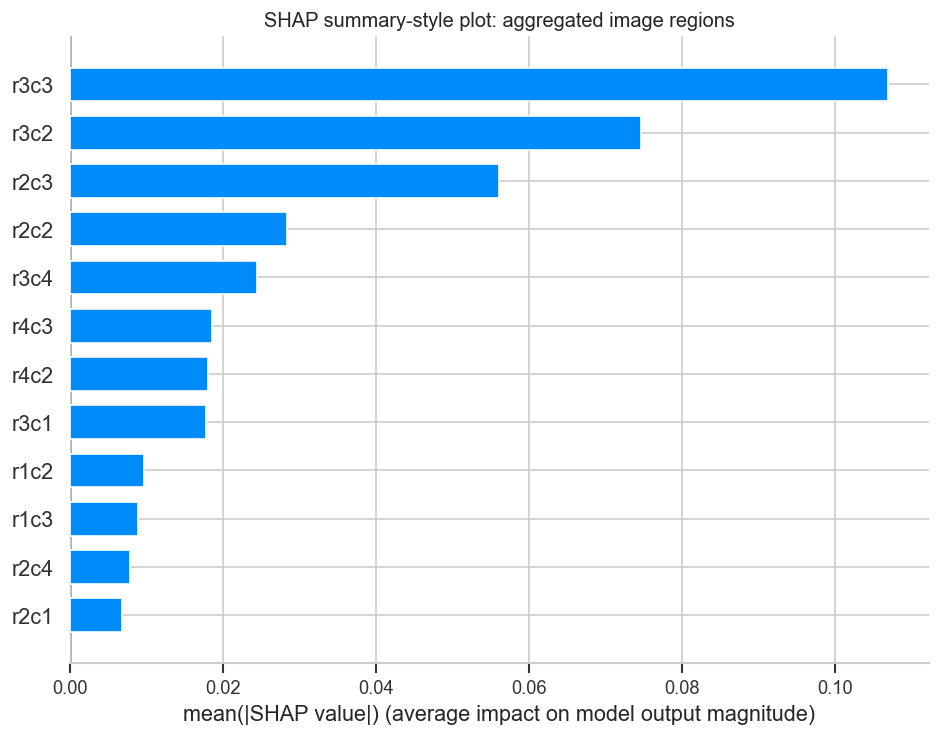

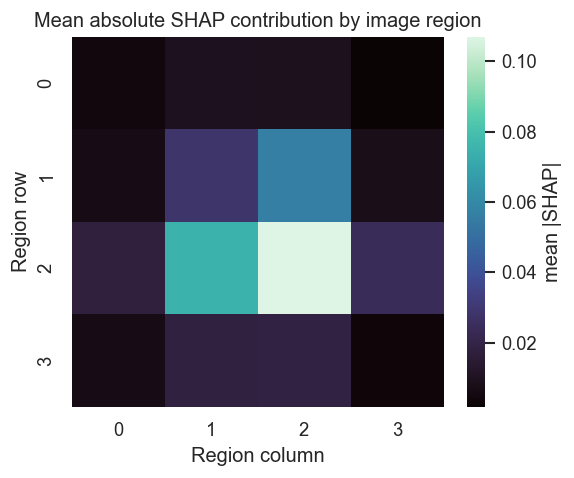

In [73]:
if shap_results["available"]:
    region_values = shap_results["region_values"]
    region_names = shap_results["region_names"]

    fig = plt.figure(figsize=(8, 5))
    shap.summary_plot(
        region_values,
        feature_names=region_names,
        plot_type="bar",
        show=False,
        max_display=12,
    )
    plt.title("SHAP summary-style plot: aggregated image regions")
    plt.tight_layout()
    fig.savefig(EXPLANATION_DIR / "shap_summary_regions.png", bbox_inches="tight")
    plt.show()

    mean_abs = np.mean(np.abs(region_values), axis=0).reshape(4, 4)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(mean_abs, cmap="mako", ax=ax, cbar_kws={"label": "mean |SHAP|"})
    ax.set_title("Mean absolute SHAP contribution by image region")
    ax.set_xlabel("Region column")
    ax.set_ylabel("Region row")
    fig.savefig(EXPLANATION_DIR / "shap_summary_region_heatmap.png", bbox_inches="tight")
    plt.show()
else:
    print("SHAP summary plot not produced because SHAP was unavailable or failed:", shap_results["reason"])

For a local waterfall-style view, we aggregate one image's SHAP values into regions and display the largest positive and negative contributions. This is a simplification of a pixel-level waterfall because raw image features are too many to read directly.

What we gain from this step: a local contribution explanation for one selected prediction.

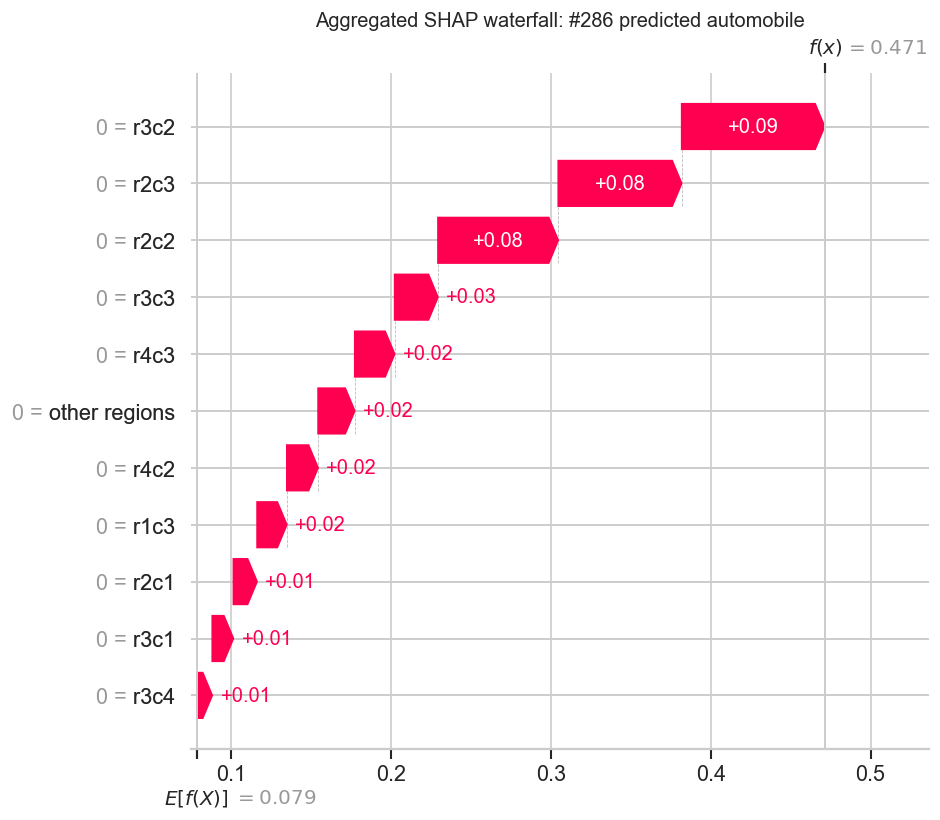

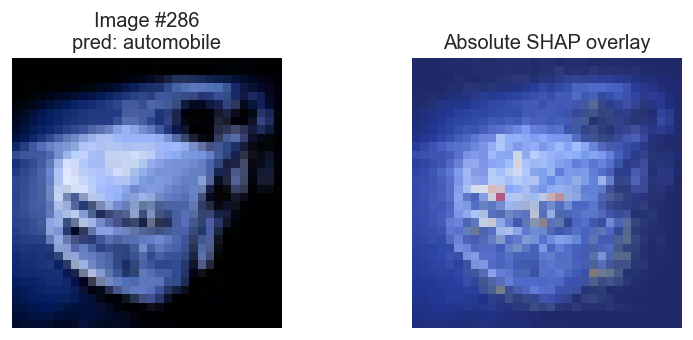

In [74]:
if shap_results["available"]:
    local_i = 0
    idx = shap_results["sample_indices"][local_i]
    pred_class = int(shap_results["predicted_classes"][local_i])
    pred_prob = float(model.predict(x_test[idx:idx + 1], verbose=0)[0, pred_class])
    base_prob = float(shap_results["background_base_probs"][pred_class])

    values = shap_results["region_values"][local_i].copy()
    names = np.array(shap_results["region_names"])
    order = np.argsort(np.abs(values))[::-1]
    top_order = order[:10]
    other_value = values[order[10:]].sum() if len(order) > 10 else 0.0
    waterfall_values = np.concatenate([values[top_order], [other_value]])
    waterfall_names = list(names[top_order]) + ["other regions"]

    # Rescale the aggregated values so the plot ends near the observed probability difference.
    total = waterfall_values.sum()
    target_delta = pred_prob - base_prob
    if abs(total) > 1e-8:
        waterfall_values = waterfall_values * (target_delta / total)

    explanation = shap.Explanation(
        values=waterfall_values,
        base_values=base_prob,
        data=np.zeros_like(waterfall_values),
        feature_names=waterfall_names,
    )

    fig = plt.figure(figsize=(8, 5))
    try:
        shap.plots.waterfall(explanation, show=False, max_display=12)
        plt.title(f"Aggregated SHAP waterfall: #{idx} predicted {class_names[pred_class]}")
    except Exception:
        signed_order = np.argsort(waterfall_values)
        plt.barh(np.array(waterfall_names)[signed_order], waterfall_values[signed_order])
        plt.axvline(0, color="black", linewidth=1)
        plt.xlabel("Approximate contribution to predicted probability")
        plt.title(f"Aggregated local SHAP contributions: #{idx}")
    plt.tight_layout()
    fig.savefig(EXPLANATION_DIR / "shap_waterfall_aggregated.png", bbox_inches="tight")
    plt.show()

    image_values = np.abs(shap_results["values"][local_i]).sum(axis=2)
    image_values = image_values / (image_values.max() + 1e-8)
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    axes[0].imshow(x_test[idx])
    axes[0].set_title(f"Image #{idx}\npred: {class_names[pred_class]}")
    axes[0].axis("off")
    axes[1].imshow(x_test[idx])
    axes[1].imshow(image_values, cmap="coolwarm", alpha=0.55)
    axes[1].set_title("Absolute SHAP overlay")
    axes[1].axis("off")
    plt.tight_layout()
    fig.savefig(EXPLANATION_DIR / "shap_local_overlay.png", bbox_inches="tight")
    plt.show()
else:
    print("SHAP waterfall-style plot not produced because SHAP was unavailable or failed:", shap_results["reason"])

**SHAP interpretation.** The summary-style plot shows which coarse image regions had the largest average contribution among the selected images. The waterfall-style plot is local and explains one prediction. Because this is an aggregated image explanation, the numbers should be interpreted as approximate region evidence, not exact causal pixel effects.

## LIME Image Explanation

LIME perturbs superpixels and fits a simple local model around one image. This can differ from Grad-CAM because LIME observes how predictions change when visible regions are hidden, while Grad-CAM uses model gradients.

What we gain from this step: model-agnostic superpixel explanations for both correct and wrong predictions.

LIME explanations created for indices: [150, 286, 415, 451]


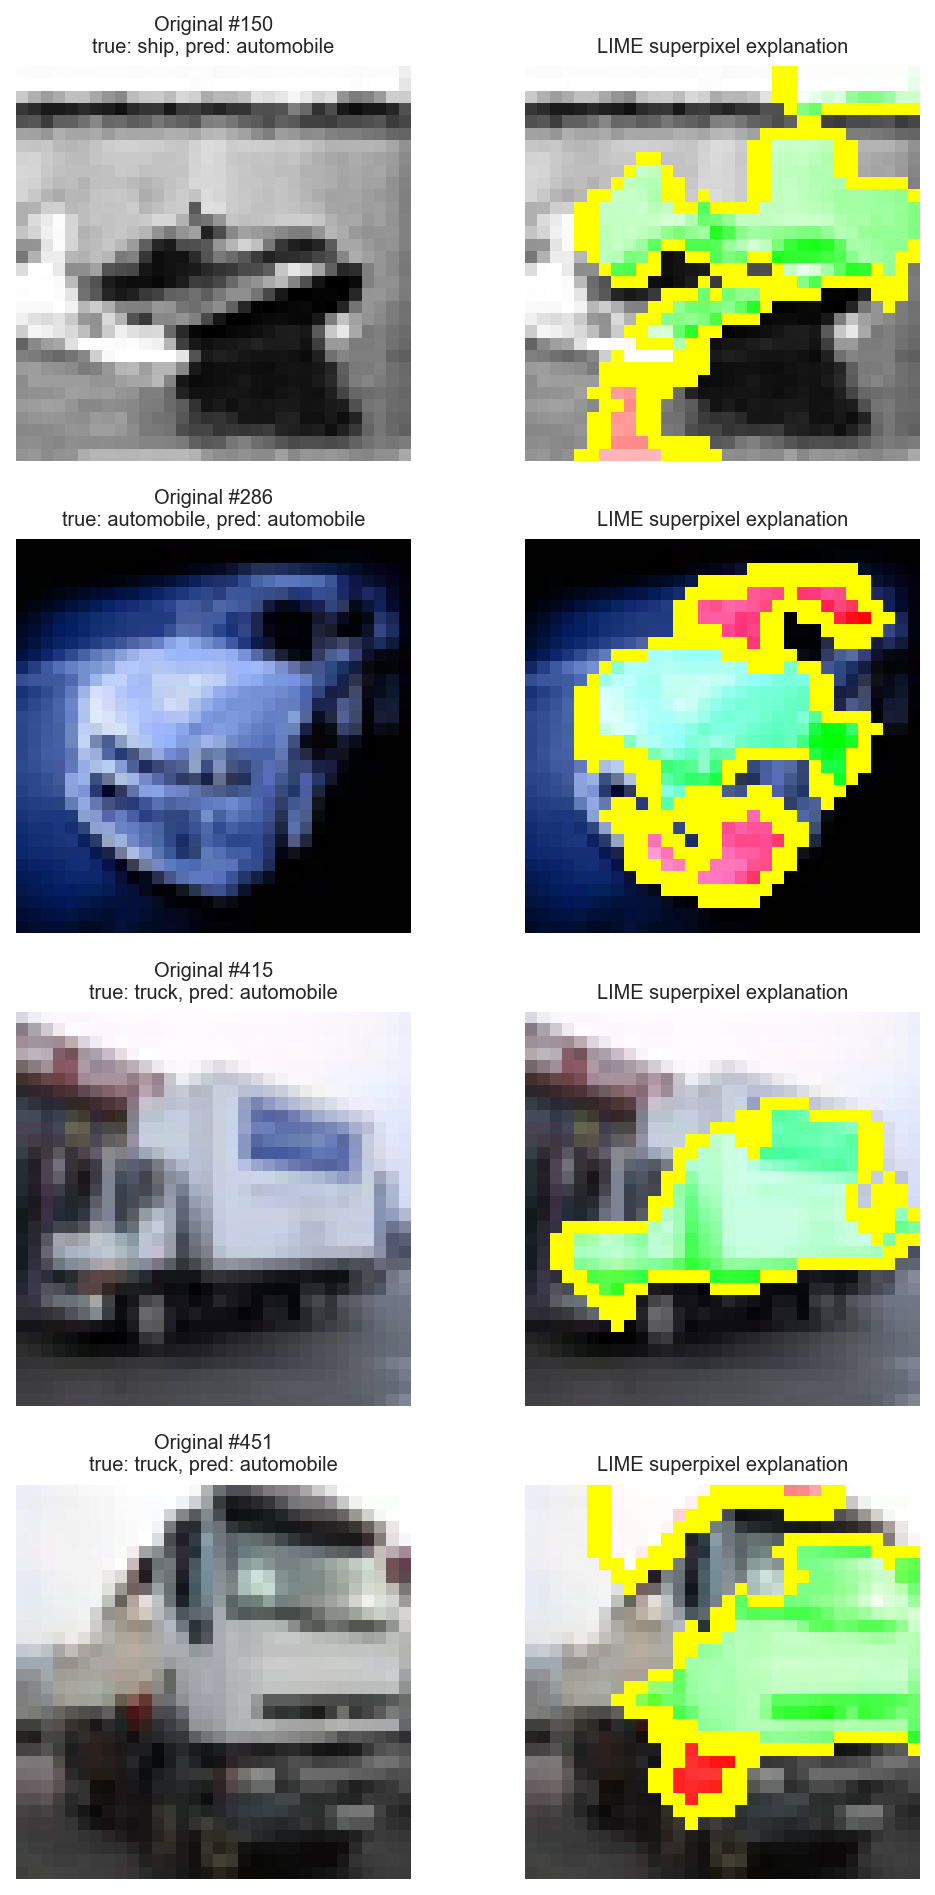

LIME explanation image saved and rendered from: outputs\xai_explanations\lime_superpixel_explanations.png


In [75]:
lime_results = {}

from IPython.display import Image as IPyImage, display as ipy_display
from IPython.utils import io


def lime_predict_fn(images):
    images = np.asarray(images).astype("float32")
    images = np.clip(images, 0, 1)
    return model.predict(images, verbose=0)


def lime_segmentation_fn(image):
    return slic(image, n_segments=35, compactness=8, sigma=0.5, start_label=1)


def explain_instance_safely(explainer, image, predict_fn, segmentation_fn):
    lime_kwargs = dict(
        top_labels=3,
        hide_color=0,
        num_samples=100,
        segmentation_fn=segmentation_fn,
        random_seed=RANDOM_SEED,
    )

    # capture_output suppresses tqdm/widget/progress display outputs from LIME.
    with io.capture_output() as captured:
        try:
            explanation = explainer.explain_instance(
                image,
                predict_fn,
                progress_bar=False,
                **lime_kwargs,
            )
        except TypeError:
            # Older LIME versions may not support progress_bar.
            explanation = explainer.explain_instance(
                image,
                predict_fn,
                **lime_kwargs,
            )

    return explanation


def render_lime_results_inline(lime_results):
    if not lime_results:
        print("No LIME plots were produced because lime_results is empty.")
        return

    plot_path = EXPLANATION_DIR / "lime_superpixel_explanations.png"

    n_rows = len(lime_results)
    fig, axes = plt.subplots(n_rows, 2, figsize=(7, 3 * n_rows))
    axes = np.asarray(axes).reshape(n_rows, 2)

    for row_axes, (idx, result) in zip(axes, sorted(lime_results.items())):
        row = prediction_df[prediction_df["index"] == idx].iloc[0]

        row_axes[0].imshow(x_test[idx])
        row_axes[0].set_title(
            f"Original #{idx}\ntrue: {row['true_label']}, pred: {row['predicted_label']}",
            fontsize=9,
        )
        row_axes[0].axis("off")

        row_axes[1].imshow(mark_boundaries(result["image"], result["mask"]))
        row_axes[1].set_title("LIME superpixel explanation", fontsize=9)
        row_axes[1].axis("off")

    plt.tight_layout()
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.close(fig)

    ipy_display(IPyImage(filename=str(plot_path)))
    print(f"LIME explanation image saved and rendered from: {plot_path}")


if optional_imports["lime"][0] == "available" and optional_imports["scikit-image"][0] == "available":
    lime_explainer = lime_image.LimeImageExplainer(random_state=RANDOM_SEED)

    lime_indices = pd.concat([
        selected_correct_df.head(1),
        selected_analysis_wrong_df,
    ])["index"].astype(int).to_list()

    for idx in lime_indices:
        explanation = explain_instance_safely(
            lime_explainer,
            x_test[idx],
            lime_predict_fn,
            lime_segmentation_fn,
        )

        pred_class = int(
            prediction_df.loc[
                prediction_df["index"] == idx,
                "predicted_class",
            ].iloc[0]
        )

        image, mask = explanation.get_image_and_mask(
            pred_class,
            positive_only=False,
            num_features=6,
            hide_rest=False,
        )
        lime_results[idx] = {
            "explanation": explanation,
            "image": image,
            "mask": mask,
            "predicted_class": pred_class,
        }

    print("LIME explanations created for indices:", sorted(lime_results))
    render_lime_results_inline(lime_results)

else:
    print("LIME was not run because lime or scikit-image is unavailable.")

The LIME masks below show superpixels that support or oppose the predicted class. Boundaries mark the perturbed regions used by the local explanation.


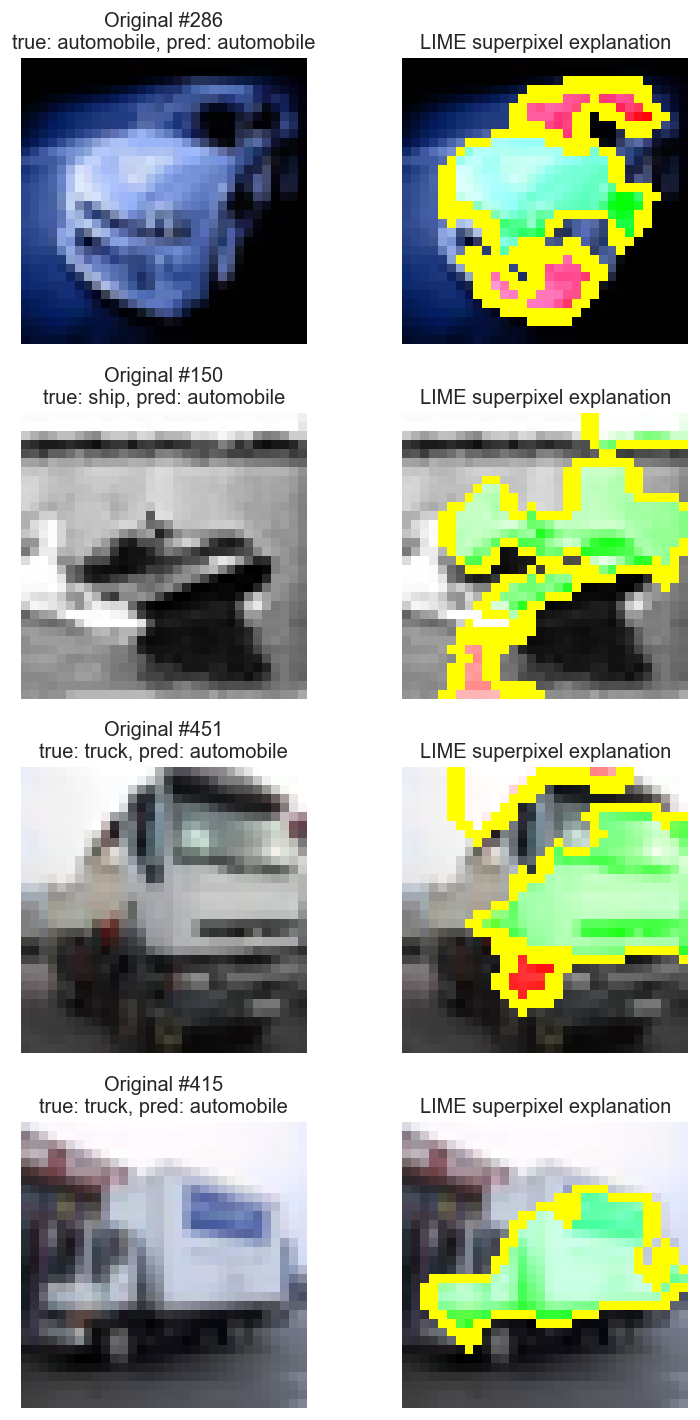

In [76]:
if lime_results:
    fig, axes = plt.subplots(len(lime_results), 2, figsize=(7, 3 * len(lime_results)))
    if len(lime_results) == 1:
        axes = axes[np.newaxis, :]

    for row_axes, (idx, result) in zip(axes, lime_results.items()):
        row = prediction_df[prediction_df["index"] == idx].iloc[0]
        row_axes[0].imshow(x_test[idx])
        row_axes[0].set_title(f"Original #{idx}\ntrue: {row['true_label']}, pred: {row['predicted_label']}")
        row_axes[0].axis("off")

        row_axes[1].imshow(mark_boundaries(result["image"], result["mask"]))
        row_axes[1].set_title("LIME superpixel explanation")
        row_axes[1].axis("off")

    plt.tight_layout()
    fig.savefig(EXPLANATION_DIR / "lime_superpixel_explanations.png", bbox_inches="tight")
    plt.show()
else:
    print("No LIME plots were produced.")

**LIME interpretation.** If highlighted superpixels land on the object, the local evidence is more semantically meaningful. If they land on background or a small ambiguous texture, the prediction may be relying on less stable cues. LIME can disagree with Grad-CAM because it tests local perturbations instead of reading gradients.

## ELI5 / Feature Importance Visualization

Direct ELI5 explanations for modern eager TensorFlow CNNs are often not reliable. Instead, we use an honest ELI5-compatible surrogate: downsample images, train a lightweight logistic regression model to imitate the CNN's predictions on a small subset, and use ELI5 permutation importance on that surrogate.



In [77]:
eli5_results = {
    "available": False,
    "reason": "",
    "importance_map": None,
    "surrogate_accuracy": None,
}


def downsample_images(images, size=(8, 8)):
    if resize is not None:
        resized = np.stack([
            resize(image, (*size, 3), anti_aliasing=True, preserve_range=True)
            for image in images
        ]).astype("float32")
    else:
        resized = tf.image.resize(images, size).numpy().astype("float32")
    return resized


if optional_imports["eli5"][0] == "available":
    try:
        surrogate_train_count = 1000
        surrogate_valid_count = 200
        surrogate_pool = train_indices[:surrogate_train_count + surrogate_valid_count]
        surrogate_images = x_train[surrogate_pool]
        cnn_pseudo_labels = np.argmax(model.predict(surrogate_images, batch_size=128, verbose=0), axis=1)

        small_images = downsample_images(surrogate_images, size=(8, 8))
        flat_features = small_images.reshape(len(small_images), -1)
        X_sur_train = flat_features[:surrogate_train_count]
        y_sur_train = cnn_pseudo_labels[:surrogate_train_count]
        X_sur_valid = flat_features[surrogate_train_count:]
        y_sur_valid = cnn_pseudo_labels[surrogate_train_count:]

        surrogate = LogisticRegression(
            max_iter=300,
            random_state=RANDOM_SEED,
            n_jobs=None,
        )
        surrogate.fit(X_sur_train, y_sur_train)
        surrogate_accuracy = surrogate.score(X_sur_valid, y_sur_valid)

        perm = PermutationImportance(
            surrogate,
            scoring="accuracy",
            n_iter=3,
            random_state=RANDOM_SEED,
        )
        perm.fit(X_sur_valid, y_sur_valid)

        importances = np.maximum(perm.feature_importances_, 0)
        importance_map = importances.reshape(8, 8, 3).sum(axis=2)
        importance_map = importance_map / (importance_map.max() + 1e-8)

        eli5_results.update({
            "available": True,
            "importance_map": importance_map,
            "surrogate_accuracy": surrogate_accuracy,
        })
        print(f"ELI5-compatible surrogate accuracy against CNN pseudo-labels: {surrogate_accuracy:.3f}")
    except Exception as exc:
        eli5_results["reason"] = repr(exc)
        print("ELI5 surrogate failed:", repr(exc))
else:
    eli5_results["reason"] = optional_imports["eli5"][1]
    print("ELI5 is unavailable:", eli5_results["reason"])

ELI5-compatible surrogate accuracy against CNN pseudo-labels: 0.545


The visualization below shows which low-resolution image regions mattered most to the surrogate model. It should be read as an approximation of the CNN's behavior, not as direct evidence from the CNN layers.

What we gain from this step: an ELI5-style feature importance plot with clear limitations.

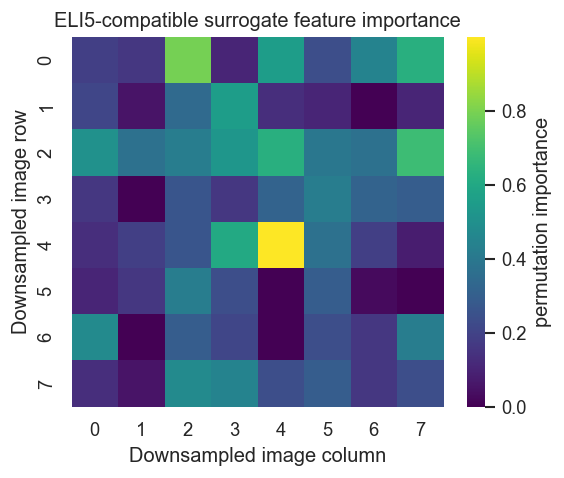

In [78]:
if eli5_results["available"]:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        eli5_results["importance_map"],
        cmap="viridis",
        ax=ax,
        cbar_kws={"label": "permutation importance"},
    )
    ax.set_title("ELI5-compatible surrogate feature importance")
    ax.set_xlabel("Downsampled image column")
    ax.set_ylabel("Downsampled image row")
    fig.savefig(EXPLANATION_DIR / "eli5_surrogate_feature_importance.png", bbox_inches="tight")
    plt.show()
else:
    print("ELI5 feature-importance visualization not produced:", eli5_results["reason"])

**ELI5 interpretation.** This surrogate explains which downsampled regions helped a simple model imitate the CNN. If the surrogate accuracy is low, the feature importance is less faithful. Even when accuracy is reasonable, it remains a compressed approximation rather than a direct CNN explanation.

## Detailed Misclassification Analysis

We now analyze at least 3 misclassified images. For each image, we include the original image, prediction information, Grad-CAM overlay, and LIME if available. The written analysis answers what the model focused on, why the misclassification may have happened, and what could improve training.


In [79]:
def group_label(label):
    animals = {"bird", "cat", "deer", "dog", "frog", "horse"}
    vehicles = {"airplane", "automobile", "ship", "truck"}
    return "animal" if label in animals else "vehicle" if label in vehicles else "other"


def likely_error_reason(true_label, predicted_label, confidence, focus_region):
    if group_label(true_label) == group_label(predicted_label):
        return (
            f"The true and predicted classes are both {group_label(true_label)} classes, so small CIFAR-10 textures "
            "and similar shapes may have made them hard to separate."
        )
    if confidence >= 0.5:
        return (
            "The model was fairly confident, which suggests it found a misleading visual cue that looked like the predicted class."
        )
    return (
        "The model confidence is modest, so the image may be ambiguous, low-resolution, or missing distinctive features."
    )


def training_improvement_text(true_label, predicted_label):
    suggestions = [
        "train for more epochs on the full CIFAR-10 training set",
        "use stronger but label-safe augmentation",
        "add regularization and tune the learning rate",
        "try a deeper CNN or transfer learning with fine-tuning",
    ]
    if group_label(true_label) == group_label(predicted_label):
        suggestions.append("add examples or augmentation that separate visually similar classes")
    else:
        suggestions.append("reduce background reliance with better cropping or augmentation")
    return "; ".join(suggestions) + "."


gradcam_wrong_by_index = {record["index"]: record for record in gradcam_wrong}
analysis_records = []

for _, row in selected_analysis_wrong_df.iterrows():
    idx = int(row["index"])
    record = gradcam_wrong_by_index[idx]
    focus_region = record["focus"]["center_of_mass"]
    true_label = row["true_label"]
    predicted_label = row["predicted_label"]
    confidence = float(row["confidence"])
    reason = likely_error_reason(true_label, predicted_label, confidence, focus_region)
    improvements = training_improvement_text(true_label, predicted_label)
    analysis_records.append({
        "index": idx,
        "true_label": true_label,
        "predicted_label": predicted_label,
        "confidence": confidence,
        "gradcam_focus": focus_region,
        "likely_reason": reason,
        "training_improvements": improvements,
    })

analysis_df = pd.DataFrame(analysis_records)
display(analysis_df)

,index,true_label,predicted_label,confidence,gradcam_focus,likely_reason,training_improvements
0,150,ship,automobile,0.465777,middle-center,The true and predicted classes are both vehicl...,train for more epochs on the full CIFAR-10 tra...
1,451,truck,automobile,0.443042,middle-center,The true and predicted classes are both vehicl...,train for more epochs on the full CIFAR-10 tra...
2,415,truck,automobile,0.431410,middle-center,The true and predicted classes are both vehicl...,train for more epochs on the full CIFAR-10 tra...


The panel below places the original image, Grad-CAM overlay, and LIME mask side by side for the misclassified cases. If LIME was unavailable, the panel still includes the other two views and the limitation is documented.


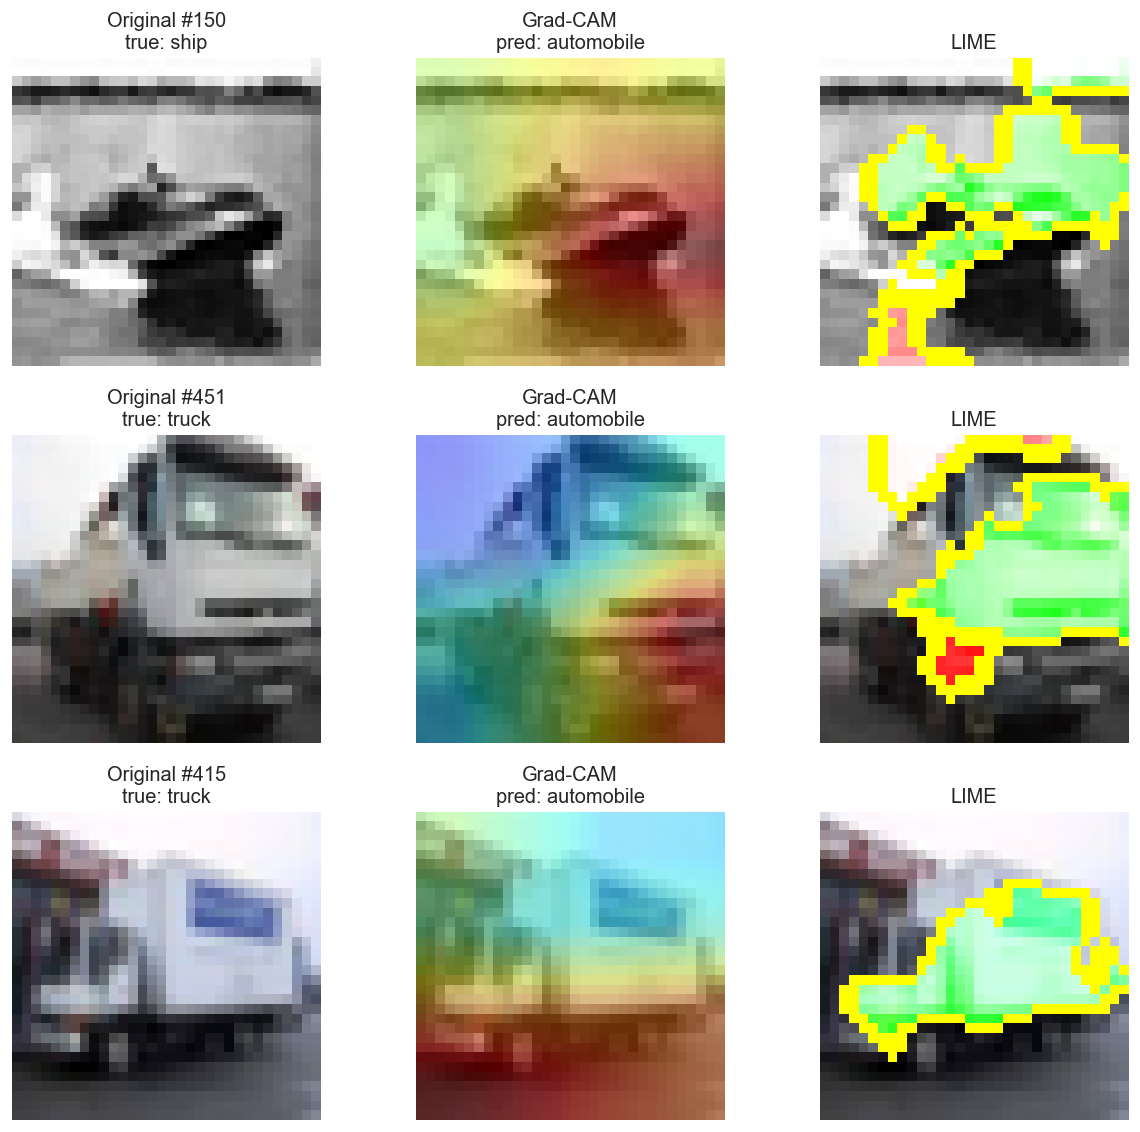

In [80]:
count = len(analysis_df)
panel_cols = 3 if lime_results else 2
fig, axes = plt.subplots(count, panel_cols, figsize=(3.5 * panel_cols, 3.2 * count))
if count == 1:
    axes = axes[np.newaxis, :]

for row_axes, (_, analysis_row) in zip(axes, analysis_df.iterrows()):
    idx = int(analysis_row["index"])
    grad_record = gradcam_wrong_by_index[idx]

    row_axes[0].imshow(x_test[idx])
    row_axes[0].set_title(f"Original #{idx}\ntrue: {analysis_row['true_label']}")
    row_axes[0].axis("off")

    row_axes[1].imshow(grad_record["overlay"])
    row_axes[1].set_title(f"Grad-CAM\npred: {analysis_row['predicted_label']}")
    row_axes[1].axis("off")

    if lime_results:
        if idx in lime_results:
            row_axes[2].imshow(mark_boundaries(lime_results[idx]["image"], lime_results[idx]["mask"]))
            row_axes[2].set_title("LIME")
            row_axes[2].axis("off")
        else:
            row_axes[2].imshow(x_test[idx])
            row_axes[2].set_title("LIME not run")
            row_axes[2].axis("off")

plt.tight_layout()
fig.savefig(EXPLANATION_DIR / "misclassification_analysis_panel.png", bbox_inches="tight")
plt.show()

The next cell writes the misclassification analysis in plain language. This is generated from the actual selected examples, so the text matches the current run.

In [81]:
from IPython.display import Markdown, display

markdown_lines = ["### Written Misclassification Analysis"]
for _, row in analysis_df.iterrows():
    markdown_lines.append(
        f"""

        **Image #{int(row['index'])}: true `{row['true_label']}`, predicted `{row['predicted_label']}` with confidence `{row['confidence']:.3f}`**

        - **What features did the model focus on?** Grad-CAM places the strongest coarse focus around the `{row['gradcam_focus']}` part of the image. The LIME mask, when shown above, marks the superpixels that locally changed the predicted class score.
        - **Why did the misclassification occur?** {row['likely_reason']} The 32 by 32 resolution also makes fine object details difficult to separate.
        - **What could be improved in training?** {row['training_improvements']}
        """
    )

display(Markdown("\n".join(markdown_lines)))

### Written Misclassification Analysis


        **Image #150: true `ship`, predicted `automobile` with confidence `0.466`**

        - **What features did the model focus on?** Grad-CAM places the strongest coarse focus around the `middle-center` part of the image. The LIME mask, when shown above, marks the superpixels that locally changed the predicted class score.
        - **Why did the misclassification occur?** The true and predicted classes are both vehicle classes, so small CIFAR-10 textures and similar shapes may have made them hard to separate. The 32 by 32 resolution also makes fine object details difficult to separate.
        - **What could be improved in training?** train for more epochs on the full CIFAR-10 training set; use stronger but label-safe augmentation; add regularization and tune the learning rate; try a deeper CNN or transfer learning with fine-tuning; add examples or augmentation that separate visually similar classes.
        


        **Image #451: true `truck`, predicted `automobile` with confidence `0.443`**

        - **What features did the model focus on?** Grad-CAM places the strongest coarse focus around the `middle-center` part of the image. The LIME mask, when shown above, marks the superpixels that locally changed the predicted class score.
        - **Why did the misclassification occur?** The true and predicted classes are both vehicle classes, so small CIFAR-10 textures and similar shapes may have made them hard to separate. The 32 by 32 resolution also makes fine object details difficult to separate.
        - **What could be improved in training?** train for more epochs on the full CIFAR-10 training set; use stronger but label-safe augmentation; add regularization and tune the learning rate; try a deeper CNN or transfer learning with fine-tuning; add examples or augmentation that separate visually similar classes.
        


        **Image #415: true `truck`, predicted `automobile` with confidence `0.431`**

        - **What features did the model focus on?** Grad-CAM places the strongest coarse focus around the `middle-center` part of the image. The LIME mask, when shown above, marks the superpixels that locally changed the predicted class score.
        - **Why did the misclassification occur?** The true and predicted classes are both vehicle classes, so small CIFAR-10 textures and similar shapes may have made them hard to separate. The 32 by 32 resolution also makes fine object details difficult to separate.
        - **What could be improved in training?** train for more epochs on the full CIFAR-10 training set; use stronger but label-safe augmentation; add regularization and tune the learning rate; try a deeper CNN or transfer learning with fine-tuning; add examples or augmentation that separate visually similar classes.
        

## Correct vs Misclassified Comparison

Correct predictions should ideally focus on the object or the most discriminative part of it. Misclassified predictions often focus on background, partial textures, or regions shared with a visually similar class. In this lightweight model, mistakes are expected because training was intentionally limited, so explanation patterns should be treated as diagnostic clues rather than final conclusions.

In [82]:
correct_focus = [record["focus"]["center_of_mass"] for record in gradcam_correct]
wrong_focus = [record["focus"]["center_of_mass"] for record in gradcam_wrong[:3]]

comparison_df = pd.DataFrame({
    "group": ["correct"] * len(correct_focus) + ["misclassified"] * len(wrong_focus),
    "gradcam_focus_region": correct_focus + wrong_focus,
})
display(comparison_df)

,group,gradcam_focus_region
0,correct,middle-center
1,correct,middle-center
2,correct,middle-center
3,misclassified,middle-center
4,misclassified,middle-center
5,misclassified,middle-center


## Final XAI Method Comparison

Different XAI methods can disagree because they answer different questions. Grad-CAM asks about gradient-weighted convolutional regions, SHAP asks about feature contributions, LIME asks about local superpixel perturbations, and ELI5/permutation importance asks how features affect a surrogate or estimator score.


In [83]:
method_comparison = pd.DataFrame([
    {
        "method": "Grad-CAM",
        "explanation type": "local",
        "model-specific or model-agnostic": "model-specific",
        "output visualization": "class heatmap overlay",
        "strengths": "fast and natural for CNNs",
        "limitations": "coarse; depends on last conv layer; not causal proof",
        "usefulness for this CNN": "high for visual focus inspection",
    },
    {
        "method": "SHAP",
        "explanation type": "local and summary-style",
        "model-specific or model-agnostic": "mostly model-agnostic idea; GradientExplainer uses model gradients",
        "output visualization": "aggregated region summary and waterfall-style plot",
        "strengths": "contribution-based and comparable across features",
        "limitations": "expensive and noisy for high-dimensional images",
        "usefulness for this CNN": "moderate; useful after region aggregation",
    },
    {
        "method": "LIME",
        "explanation type": "local",
        "model-specific or model-agnostic": "model-agnostic",
        "output visualization": "superpixel mask",
        "strengths": "shows local perturbation evidence",
        "limitations": "sensitive to segmentation and perturbation settings",
        "usefulness for this CNN": "high for checking object vs background reliance",
    },
    {
        "method": "ELI5 surrogate",
        "explanation type": "global-ish feature importance",
        "model-specific or model-agnostic": "surrogate model explanation",
        "output visualization": "permutation-importance heatmap",
        "strengths": "simple and lightweight",
        "limitations": "explains a surrogate, not direct CNN internals",
        "usefulness for this CNN": "moderate as a compressed sanity check",
    },
])

display(method_comparison)
method_comparison.to_csv(OUTPUT_DIR / "xai_method_comparison.csv", index=False)

,method,explanation type,model-specific or model-agnostic,output visualization,strengths,limitations,usefulness for this CNN
0,Grad-CAM,local,model-specific,class heatmap overlay,fast and natural for CNNs,coarse; depends on last conv layer; not causal...,high for visual focus inspection
1,SHAP,local and summary-style,mostly model-agnostic idea; GradientExplainer ...,aggregated region summary and waterfall-style ...,contribution-based and comparable across features,expensive and noisy for high-dimensional images,moderate; useful after region aggregation
2,LIME,local,model-agnostic,superpixel mask,shows local perturbation evidence,sensitive to segmentation and perturbation set...,high for checking object vs background reliance
3,ELI5 surrogate,global-ish feature importance,surrogate model explanation,permutation-importance heatmap,simple and lightweight,"explains a surrogate, not direct CNN internals",moderate as a compressed sanity check
